In [1]:
import numpy as np
import xarray as xr
from cdo import *
from scipy.ndimage import distance_transform_edt
from osgeo import gdal, ogr, osr
from matplotlib import pyplot as plt
import pandas as pd
import pyproj as pp
from skimage.segmentation import flood_fill

# Bedmachine
## Load Bedmachine data and build ice shelf and grounded mask

In [2]:
# Get BM data (mask, draft, ...)
# Charger le dataset
cfile_bm="NSIDC-0756_BedMachineAntarctica_19700101-20191001_V04.1.nc"
ds = xr.open_dataset(cfile_bm)

# Calculer le draft : - (surface - thickness)
draft = - (ds.surface - ds.thickness)

# Masquer les valeurs invalides (où surface ou thickness = -9999)
draft_isf = draft.where((ds.surface != -9999) & (ds.thickness != -9999) & (ds.mask == 3)).values

# Compute BM mask
mask_isf = np.where(ds.mask.values==3,1,0)
mask_grd = np.where(ds.mask.values == 2,1,0)  # Mask pour les grilles valides

## Create Bedmachine grid file for cdo remapping

In [3]:
def compute_lat_lon_and_bounds(x_min, x_max, y_min, y_max, width, height, pixel_size): 
    # prepare variable needed for cdo 
    # Create coordinates (for dataarray)
    half_res = pixel_size / 2
    x_coords =   np.linspace(x_min + half_res, x_max - half_res, width)
    y_coords = - np.linspace(y_min + half_res, y_max - half_res, height)

    # Create 2D-coordinates
    meshx,meshy = np.meshgrid(x_coords, y_coords)

    # Create the lat and lon of the grid centers
    transformer_tolonlat = pp.Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

    # compute lat/lon
    print('    compute lat/lon')
    meshlon,meshlat = transformer_tolonlat.transform(meshx,meshy)

    # Original grid
    x_coords_bnds =   np.linspace(x_min, x_max, width  + 1)  # +1 for extended grid
    y_coords_bnds = - np.linspace(y_min, y_max, height + 1)  # +1 for extended grid

    # Create 2D-coordinates for extended grid
    meshx_bnds, meshy_bnds = np.meshgrid(x_coords_bnds, y_coords_bnds)

    # Create the lat and lon of the grid corners
    print('    compute lat/lon corners')
    meshlon_bnds,meshlat_bnds = transformer_tolonlat.transform(meshx_bnds, meshy_bnds)

    return x_coords, y_coords, meshlon, meshlat, meshlon_bnds, meshlat_bnds

## Create coordinates and bounds for the BedMachine grid

In [4]:
# original resolution to ice shelf statistics 
width_500m, height_500m = 13333, 13333

x_min_500m, y_min_500m, x_max_500m, y_max_500m = -3333250.0, -3333250.0, 3333250, 3333250.0

pixel_size_x_500m = (x_max_500m - x_min_500m) / width_500m
pixel_size_y_500m = (y_max_500m - y_min_500m) / height_500m

print('compute lat/lon and bounds for the 500m grid')
x_coords_500m, y_coords_500m, meshlon_500m, meshlat_500m, meshlon_bnds_500m, meshlat_bnds_500m = compute_lat_lon_and_bounds(x_min_500m, x_max_500m, y_min_500m, y_max_500m, width_500m, height_500m, pixel_size_x_500m)

compute lat/lon and bounds for the 500m grid
    compute lat/lon
    compute lat/lon corners


## Write BedMachine grid ready for cdo interpolation

In [5]:
# create grids for cdo interpolation at 500m resolution 
ds_grid_bm_500m = xr.Dataset(
    coords={
        'y': y_coords_500m,  # or use y_coords if you have them
        'x': x_coords_500m,  # or use x_coords if you have them
        'lon':  xr.DataArray(data=meshlon_500m, dims=['y', 'x'], name='lon',
                            attrs={
                                'standard_name': 'longitude',
                                'units': 'degrees_east',
                                'bounds': 'lon_bnds'
                            }
                ),
        'lat':  xr.DataArray(data=meshlat_500m, dims=['y', 'x'], name='lat',
                            attrs={
                                'standard_name': 'latitude',
                                'units': 'degrees_north',
                                'bounds': 'lat_bnds'
                            }
                ),
        # Add lon_bnds and lat_bnds as variables (not coordinates)
        'lon_bnds': xr.DataArray(
                            data=np.array([meshlon_bnds_500m[:-1,:-1], meshlon_bnds_500m[1:,:-1], meshlon_bnds_500m[1:,1:], meshlon_bnds_500m[:-1,1:]]),
                            dims=['nvertex', 'y', 'x'],
                            attrs={'coordinates': 'lon lat'},
                            name='lon_bnds'
                        ),
        'lat_bnds': xr.DataArray(
                            data=np.array([meshlat_bnds_500m[:-1,:-1], meshlat_bnds_500m[1:,:-1], meshlat_bnds_500m[1:,1:], meshlat_bnds_500m[:-1,1:]]),
                            dims=['nvertex', 'y', 'x'],
                            attrs={'coordinates': 'lon lat'},
                            name='lat_bnds'
                        )
    }  
)

ds_grid_bm_500m['mask'] = xr.DataArray(ds.mask, dims=['y', 'x'], attrs={'coordinates': 'lon lat'}, name='mask')

ds_grid_bm_500m.transpose('y','x','nvertex').to_netcdf(f'grid_bm_500m.nc')

del ds_grid_bm_500m, meshlon_bnds_500m, meshlat_bnds_500m, meshlon_500m, meshlat_500m, x_coords_500m, y_coords_500m

# NEMO
## Read NEMO domain ready for cdo
 - Compute icell array (each cell get a unique id), this array is used to define which cell is partlly grounded in Bedmachine
 - Compute Antarctica mask (0 for Antarctica cells whatever its status (grouding or floating))

In [9]:
# load NEMO
# Read NEMO data ready for cdo processing
# Read domain_cfg.nc
#fNEMO_grid='domain_cfg_O2_nco_ncra_e3.nc'
fNEMO_grid='domain_cfg_O1_nco_full_nco_simp.nc'
ds_nemo_domain=xr.open_dataset(fNEMO_grid)

## ice shelf mask
ds_nemo_domain['isf_mask']=xr.where((ds_nemo_domain.bottom_level > 0) & (ds_nemo_domain.top_level > 1), 1, 0)

# Get NEMO coast cell that contains an ice shelf
## define NEMO cell id for the ice shelf cell where we plan to apply param
lenarray = ds_nemo_domain.top_level.shape[0]*ds_nemo_domain.top_level.shape[1]
arr = np.arange(lenarray)
NEMO_icell=arr.reshape(ds_nemo_domain.top_level.shape)
NEMO_icell=np.where(ds_nemo_domain['isf_mask'] == 1,NEMO_icell,-1)
ds_nemo_domain['icell'] = xr.DataArray(NEMO_icell, dims=['y', 'x'], attrs={'coordinates': 'lat lon'}, name='icell')

# Get NEMO mask
NEMO_mask=np.where(ds_nemo_domain.bottom_level > 0, 1, 0)

# write data for sanity check
ds_nemo_domain.to_netcdf('nemo_domain.nc')

# Mask NEMO cells that are partly grounded in Bedmachine
 - 1.: Interpolate with nn icell to Bedmachine grid
 - 2.: Mask cells that are floating or ocean
 - 3.: Get list of id of the remaning cell (ie cells that are floating in NEMO but grd in Bedmachine)
 - 4.: Get the corresponding cell in NEMO as a mask
 - 5.: Remove remaining ocean cell not connected to the global ocean
 - 6.: Apply mask to top and bottom level variables 
 - 7.: Write new domain file

In [7]:
cdo = Cdo()
# 1.: Interpolate with nn icell to Bedmachine grid
BM_NEMO_icell=cdo.remapnn('grid_bm_500m.nc',input=ds_nemo_domain.icell, returnArray='icell', options='-f nc4 -v')

In [12]:
# 2.: Mask cells that are floating or ocean
BM_NEMO_icell = BM_NEMO_icell * mask_grd

# 3.: Get list of id of the remaning cell (ie cells that are floating in NEMO but grd in Bedmachine)
lst_icell = list(set(BM_NEMO_icell[BM_NEMO_icell > 0].astype(int)))

# 4.: Get the corresponding cell in NEMO as a mask
NEMO_mask_grd = np.where( np.isin(NEMO_icell,np.array(list(lst_icell))), 0, NEMO_mask)

# 5.: Remove remaining ocean cell not connected to the global ocean
#     Warning seed is specific to eORCA1 grid, it should be adapted for other grids
NEMO_ocean_masked = np.where(NEMO_mask_grd == 0, 0, ds_nemo_domain.bottom_level)
NEMO_ocean_masked = np.where(NEMO_ocean_masked > 0, 1, 0)
NEMO_mask_grd_flooded = flood_fill(NEMO_ocean_masked, (200, 200), -1, connectivity=1)
NEMO_mask_grd_flooded = np.where(NEMO_mask_grd_flooded==-1,1,0)

# 6.: Apply mask to NEMO top and bottom level variables
ds_nemo_domain=xr.open_dataset(fNEMO_grid)
ds_nemo_domain['top_level'] = ds_nemo_domain['top_level']*NEMO_mask_grd_flooded
ds_nemo_domain['bottom_level'] = ds_nemo_domain['bottom_level']*NEMO_mask_grd_flooded

# 7.: Write new dataset with masked top and bottom level
ds_nemo_domain.to_netcdf('nemo_domain_masked.nc')

# Sanity check
To do this we do a plot with NEMO ocean cell to 3, isf to 2, BM grd and NEMO isf to 0, BM grd and isf in NEMO to -1

In [13]:
ds_nemo_domain_msk=xr.open_dataset('nemo_domain_masked.nc')
bottom_level_masked = ds_nemo_domain_msk['bottom_level'].values
BM_NEMO_bottom_level=cdo.remapnn('grid_bm_500m.nc',input=ds_nemo_domain_msk.bottom_level, returnArray='bottom_level', options='-f nc4 -v')
BM_NEMO_top_level=cdo.remapnn('grid_bm_500m.nc',input=ds_nemo_domain_msk.top_level, returnArray='top_level', options='-f nc4 -v')

If all good, you should not see -1 in the plot below. -1 means that there is NEMO ice shelf cells taht contains grounded area in BM

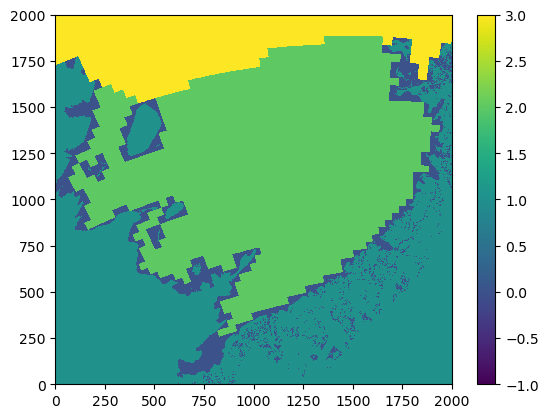

In [14]:
check_data = np.where((BM_NEMO_bottom_level>=1) & (BM_NEMO_top_level==1), 3, 0)
check_data = np.where((BM_NEMO_top_level>1), 2, check_data)
check_data = np.where((BM_NEMO_bottom_level==0) & (mask_grd==1), 1, check_data)
check_data = np.where((BM_NEMO_top_level>1) & (mask_grd==1), -1, check_data)
plt.pcolormesh(check_data[7500:9500,5500:7500],vmin=-1,vmax=3)
plt.colorbar()